In [1]:
#To do next
"""
нужно посчитать структуры нитридов углерода (графитизированные) - в папке с агпвт
посчитать для разных гетероциклов + то, что касается спектров на атомах азота
посмотреть дисперсии значений для типичных энергий
"""

'\nнужно посчитать структуры нитридов углерода (графитизированные) - в папке с агпвт\nпосчитать для разных гетероциклов + то, что касается спектров на атомах азота\nпосмотреть дисперсии значений для типичных энергий\n'

In [2]:
# старт
# разово выполнить ячейку 2
# для анализа файлов выполнить ячейку 3,4
# для деконволюции спектра - ячейки 3,5,6,8,7
"""
VGD Reader - Parse Thermo Scientific VGD Files for XPS Analysis

A Python library for reading Thermo Scientific VGD (VG Data) binary files
commonly used in X-ray Photoelectron Spectroscopy (XPS).

Note: В Jupyter Notebook все функции определены напрямую в следующей ячейке.
Относительные импорты здесь не требуются.
"""

# Все функции (read_vgd, VGDFile, parse_vgd_file и т.д.) 
# уже определены в следующей ячейке (parser.py)
pass

In [3]:
# ячейка 2 - зависимости
#============================================================
# УСТАНОВКА ЗАВИСИМОСТЕЙ ДЛЯ XPS АНАЛИЗА
# ============================================================

import sys
import subprocess
import importlib

def check_and_install(package_name, import_name=None):
    """Проверяет и устанавливает пакет если необходимо."""
    if import_name is None:
        import_name = package_name
    
    try:
        importlib.import_module(import_name)
        print(f"✅ {package_name} - уже установлен")
        return True
    except ImportError:
        print(f"⏳ Установка {package_name}...")
        try:
            subprocess.check_call([sys.executable, "-m", "pip", "install", package_name, "-q"])
            print(f"✅ {package_name} - успешно установлен")
            return True
        except Exception as e:
            print(f"❌ Ошибка установки {package_name}: {e}")
            return False

print("=" * 60)
print("📦 ПРОВЕРКА И УСТАНОВКА ЗАВИСИМОСТЕЙ")
print("=" * 60)
print(f"Python версия: {sys.version}")
print()

# Список необходимых пакетов
# Формат: (pip_name, import_name)
required_packages = [
    ("numpy", "numpy"),
    ("pandas", "pandas"),
    ("matplotlib", "matplotlib"),
    ("scipy", "scipy"),
    ("lmfit", "lmfit"),
    ("olefile", "olefile"),
    ("openpyxl", "openpyxl"),
    ("ipywidgets", "ipywidgets"),
]

# Установка всех пакетов
installation_results = {}
for pip_name, import_name in required_packages:
    installation_results[pip_name] = check_and_install(pip_name, import_name)

print()
print("=" * 60)

# Проверка результатов
all_installed = all(installation_results.values())

if all_installed:
    print("✅ ВСЕ ЗАВИСИМОСТИ УСТАНОВЛЕНЫ УСПЕШНО!")
    print()
    print("📊 Версии установленных пакетов:")
    
    # Вывод версий
    try:
        import numpy
        print(f"   • numpy: {numpy.__version__}")
    except:
        pass
    
    try:
        import pandas
        print(f"   • pandas: {pandas.__version__}")
    except:
        pass
    
    try:
        import matplotlib
        print(f"   • matplotlib: {matplotlib.__version__}")
    except:
        pass
    
    try:
        import scipy
        print(f"   • scipy: {scipy.__version__}")
    except:
        pass
    
    try:
        import lmfit
        print(f"   • lmfit: {lmfit.__version__}")
    except:
        pass
    
    try:
        import olefile
        print(f"   • olefile: {olefile.__version__}")
    except:
        pass
    
    try:
        import openpyxl
        print(f"   • openpyxl: {openpyxl.__version__}")
    except:
        pass
    
    try:
        import ipywidgets
        print(f"   • ipywidgets: {ipywidgets.__version__}")
    except:
        pass
    
    print()
    print("💡 Теперь можно переходить к следующей ячейке!")
    
else:
    print("⚠️ НЕКОТОРЫЕ ПАКЕТЫ НЕ УДАЛОСЬ УСТАНОВИТЬ")
    print()
    print("Пакеты с ошибками:")
    for package, success in installation_results.items():
        if not success:
            print(f"   ❌ {package}")
    
    print()
    print(" Попробуйте установить их вручную:")
    print("   pip install <package_name>")

print("=" * 60)

📦 ПРОВЕРКА И УСТАНОВКА ЗАВИСИМОСТЕЙ
Python версия: 3.14.5 (v3.14.5:5607950ef23, May 10 2026, 07:38:09) [Clang 21.0.0 (clang-2100.0.123.102)]

✅ numpy - уже установлен
✅ pandas - уже установлен
✅ matplotlib - уже установлен
✅ scipy - уже установлен
✅ lmfit - уже установлен
✅ olefile - уже установлен
✅ openpyxl - уже установлен
✅ ipywidgets - уже установлен

✅ ВСЕ ЗАВИСИМОСТИ УСТАНОВЛЕНЫ УСПЕШНО!

📊 Версии установленных пакетов:
   • numpy: 2.4.6
   • pandas: 3.0.3
   • matplotlib: 3.10.9
   • scipy: 1.17.1
   • lmfit: 1.3.4
   • olefile: 0.47
   • openpyxl: 3.1.5
   • ipywidgets: 8.1.8

💡 Теперь можно переходить к следующей ячейке!


In [1]:
# ячейка 3 - сам парсер
"""
VGD File Parser

Thermo Scientific VGD files use Microsoft OLE2 Compound File format.
Data is stored as Kinetic Energy and converted to Binding Energy using:
    BE = Source_Energy - KE

Supports both single-spectrum and multi-spectrum VGD files.
"""

import os
import re
import struct
from dataclasses import dataclass, field
from typing import Dict, List, Optional, Tuple, Union

import numpy as np

try:
    import olefile
except ImportError:
    olefile = None


@dataclass
class VGDMetadata:
    """Metadata extracted from VGD file OLE properties."""
    title: str = ""
    subject: str = ""
    author: str = ""
    create_time: str = ""
    saved_time: str = ""


@dataclass
class VGDAcquisitionParams:
    """Acquisition parameters from VGD file."""
    source_energy: float = 1486.68  # Default Al K-alpha
    pass_energy: Optional[float] = None
    work_function: Optional[float] = None
    dwell_time: Optional[float] = None
    periods: Optional[int] = None
    txf_coefficients: List[float] = field(default_factory=list)


@dataclass
class VGDSpectrum:
    """A single XPS spectrum from a VGD file."""
    
    # Core data
    binding_energy: np.ndarray
    kinetic_energy: np.ndarray
    intensity: np.ndarray  # Raw counts
    corrected_intensity: np.ndarray  # Normalized by dwell*periods
    
    # Spectrum info
    core_level: str = ""
    spectrum_index: int = 0
    total_spectra: int = 1
    num_points: int = 0
    
    # Energy range
    be_start: float = 0.0
    be_end: float = 0.0
    be_step: float = 0.0
    ke_start: float = 0.0
    ke_step: float = 0.0
    
    # Acquisition parameters
    source_energy: float = 1486.68
    source_label: str = ""
    pass_energy: Optional[float] = None
    work_function: Optional[float] = None
    dwell_time: Optional[float] = None
    periods: Optional[int] = None
    
    # Transmission function
    txf_applied: bool = False
    txf_coefficients: List[float] = field(default_factory=list)
    
    # Metadata
    sample_id: str = ""
    title: str = ""
    author: str = ""
    date_created: str = ""
    time_created: str = ""
    date_saved: str = ""
    time_saved: str = ""
    technique: str = "XPS"
    
    def to_dict(self) -> Dict:
        """Convert spectrum to dictionary matching KherveFitting format."""
        return {
            'Sample ID': self.sample_id,
            'Title': self.title,
            'Author': self.author,
            'Date Created': self.date_created,
            'Time Created': self.time_created,
            'Date Saved': self.date_saved,
            'Time Saved': self.time_saved,
            'Technique': self.technique,
            'Species & Transition': self.core_level,
            'Spectrum Index': str(self.spectrum_index),
            'Total Spectra': str(self.total_spectra),
            'Source Label': self.source_label,
            'Source Energy': f"{self.source_energy:.2f}",
            'Pass Energy': f"{self.pass_energy:.2f}" if self.pass_energy else 'Unknown',
            'Work Function': f"{self.work_function:.2f}" if self.work_function else 'Unknown',
            'Dwell Time': f"{self.dwell_time:.4f}" if self.dwell_time else 'Unknown',
            'Periods': str(self.periods) if self.periods else 'Unknown',
            'Number of Points': str(self.num_points),
            'BE Start': f"{self.be_start:.2f}",
            'BE End': f"{self.be_end:.2f}",
            'BE Step': f"{abs(self.be_step):.4f}",
            'KE Start': f"{self.ke_start:.2f}",
            'KE Step': f"{abs(self.ke_step):.4f}",
            'TXF Applied': 'Yes' if self.txf_applied else 'No',
            'TXF Coefficients': ', '.join([f"{c:.6f}" for c in self.txf_coefficients]) if self.txf_coefficients else 'N/A',
            # Also include raw arrays for programmatic access
            'binding_energy': self.binding_energy.tolist(),
            'kinetic_energy': self.kinetic_energy.tolist(),
            'intensity': self.intensity.tolist(),
            'corrected_intensity': self.corrected_intensity.tolist(),
        }


@dataclass  
class VGDFile:
    """
    Represents a parsed VGD file with one or more spectra.
    
    Usage:
        vgd = VGDFile("sample.vgd")
        print(f"Found {vgd.num_spectra} spectra")
        for spectrum in vgd.spectra:
            print(spectrum.core_level, spectrum.binding_energy)
    """
    
    filepath: str
    spectra: List[VGDSpectrum] = field(default_factory=list)
    metadata: VGDMetadata = field(default_factory=VGDMetadata)
    acquisition: VGDAcquisitionParams = field(default_factory=VGDAcquisitionParams)
    
    def __post_init__(self):
        if os.path.exists(self.filepath):
            self._parse()
    
    @property
    def num_spectra(self) -> int:
        return len(self.spectra)
    
    @property
    def core_level(self) -> str:
        """Primary core level name from filename."""
        return extract_core_level_name(os.path.basename(self.filepath))
    
    # Convenience accessors for single-spectrum files
    @property
    def binding_energy(self) -> np.ndarray:
        """Binding energy array (first spectrum)."""
        return self.spectra[0].binding_energy if self.spectra else np.array([])
    
    @property
    def intensity(self) -> np.ndarray:
        """Raw intensity array (first spectrum)."""
        return self.spectra[0].intensity if self.spectra else np.array([])
    
    @property
    def corrected_intensity(self) -> np.ndarray:
        """Corrected intensity array (first spectrum)."""
        return self.spectra[0].corrected_intensity if self.spectra else np.array([])
    
    def _parse(self):
        """Parse the VGD file and populate spectra."""
        parsed = parse_vgd_file(self.filepath)
        
        # Store metadata
        meta = parsed['metadata']
        self.metadata = VGDMetadata(
            title=meta['title'],
            subject=meta['subject'],
            author=meta['author'],
            create_time=meta['create_time'],
            saved_time=meta['saved_time'],
        )
        
        # Store acquisition params
        self.acquisition = VGDAcquisitionParams(
            source_energy=parsed['source_energy'],
            pass_energy=parsed['pass_energy'],
            work_function=parsed['work_fn'],
            dwell_time=parsed['dwell_time'],
            periods=parsed['periods'],
            txf_coefficients=parsed['txf_coeffs'] or [],
        )
        
        # Determine source label
        source_energy = parsed['source_energy']
        if abs(source_energy - 1486.68) < 0.1:
            source_label = "Al K-alpha Monochromated"
        elif abs(source_energy - 1253.6) < 0.1:
            source_label = "Mg K-alpha"
        else:
            source_label = f"X-ray {source_energy:.2f} eV"
        
        # Parse date/time components
        create_time = meta['create_time']
        saved_time = meta['saved_time']
        date_created = create_time.split()[0] if create_time else ''
        time_created = create_time.split()[1] if create_time and len(create_time.split()) > 1 else ''
        date_saved = saved_time.split()[0] if saved_time else ''
        time_saved = saved_time.split()[1] if saved_time and len(saved_time.split()) > 1 else ''
        
        # Create spectrum objects
        core_level = self.core_level
        num_spectra = parsed.get('num_spectra', 1)
        base_name = os.path.splitext(os.path.basename(self.filepath))[0]
        
        for idx in range(num_spectra):
            calc = calculate_spectrum_data(parsed, idx)
            
            spectrum = VGDSpectrum(
                binding_energy=np.array(calc['be_values']),
                kinetic_energy=np.array(calc['ke_values']),
                intensity=np.array(calc['intensities']),
                corrected_intensity=np.array(calc['corrected_data']),
                core_level=core_level,
                spectrum_index=idx,
                total_spectra=num_spectra,
                num_points=parsed['num_points'],
                be_start=calc['be_start'],
                be_end=calc['be_end'],
                be_step=calc['be_step'],
                ke_start=parsed['ke_start'] or 0.0,
                ke_step=parsed['ke_step'] or 0.0,
                source_energy=source_energy,
                source_label=source_label,
                pass_energy=parsed['pass_energy'],
                work_function=parsed['work_fn'],
                dwell_time=parsed['dwell_time'],
                periods=parsed['periods'],
                txf_applied=calc['txf_valid'],
                txf_coefficients=parsed['txf_coeffs'] or [],
                sample_id=meta['subject'] or base_name,
                title=meta['title'],
                author=meta['author'],
                date_created=date_created,
                time_created=time_created,
                date_saved=date_saved,
                time_saved=time_saved,
                technique='XPS',
            )
            self.spectra.append(spectrum)
    
    def to_dataframe(self):
        """
        Convert to pandas DataFrame (requires pandas).
        
        Returns DataFrame with columns: BE, Intensity, Corrected_Intensity, Spectrum_Index
        """
        try:
            import pandas as pd
        except ImportError:
            raise ImportError("pandas is required for to_dataframe(). Install with: pip install pandas")
        
        dfs = []
        for spectrum in self.spectra:
            df = pd.DataFrame({
                'BE': spectrum.binding_energy,
                'KE': spectrum.kinetic_energy,
                'Intensity': spectrum.intensity,
                'Corrected_Intensity': spectrum.corrected_intensity,
                'Spectrum_Index': spectrum.spectrum_index,
                'Core_Level': spectrum.core_level,
            })
            dfs.append(df)
        
        return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()
    
    def to_excel(self, output_path: str, include_metadata: bool = True):
        """
        Export to Excel file matching KherveFitting format.
        
        Args:
            output_path: Path for output .xlsx file
            include_metadata: If True, include experimental info in column 50
        """
        try:
            import openpyxl
        except ImportError:
            raise ImportError("openpyxl is required for to_excel(). Install with: pip install openpyxl")
        
        wb = openpyxl.Workbook()
        wb.remove(wb.active)
        
        for spectrum in self.spectra:
            # Create sheet name
            if spectrum.spectrum_index == 0:
                sheet_name = spectrum.core_level
            else:
                sheet_name = f"{spectrum.core_level}{spectrum.spectrum_index}"
            
            ws = wb.create_sheet(sheet_name)
            
            # Headers
            ws.cell(row=1, column=1, value='BE')
            ws.cell(row=1, column=2, value='Corrected Data')
            ws.cell(row=1, column=3, value='Raw Data')
            
            # Data
            for i, (be, corr, raw) in enumerate(zip(
                    spectrum.binding_energy,
                    spectrum.corrected_intensity,
                    spectrum.intensity), start=2):
                ws.cell(row=i, column=1, value=round(float(be), 2))
                ws.cell(row=i, column=2, value=round(float(corr), 2))
                ws.cell(row=i, column=3, value=round(float(raw), 2))
            
            # Metadata in column 50 (matching KherveFitting)
            if include_metadata:
                exp_col = 50
                ws.cell(row=1, column=exp_col, value="Experimental Description")
                
                metadata_items = [
                    ('Sample ID', spectrum.sample_id),
                    ('Title', spectrum.title),
                    ('Author', spectrum.author),
                    ('Date Created', spectrum.date_created),
                    ('Time Created', spectrum.time_created),
                    ('Date Saved', spectrum.date_saved),
                    ('Time Saved', spectrum.time_saved),
                    ('Technique', spectrum.technique),
                    ('Species & Transition', spectrum.core_level),
                    ('Spectrum Index', str(spectrum.spectrum_index)),
                    ('Total Spectra', str(spectrum.total_spectra)),
                    ('Source Label', spectrum.source_label),
                    ('Source Energy', f"{spectrum.source_energy:.2f}"),
                    ('Pass Energy', f"{spectrum.pass_energy:.2f}" if spectrum.pass_energy else 'Unknown'),
                    ('Work Function', f"{spectrum.work_function:.2f}" if spectrum.work_function else 'Unknown'),
                    ('Dwell Time', f"{spectrum.dwell_time:.4f}" if spectrum.dwell_time else 'Unknown'),
                    ('Periods', str(spectrum.periods) if spectrum.periods else 'Unknown'),
                    ('Number of Points', str(spectrum.num_points)),
                    ('BE Start', f"{spectrum.be_start:.2f}"),
                    ('BE End', f"{spectrum.be_end:.2f}"),
                    ('BE Step', f"{abs(spectrum.be_step):.4f}"),
                    ('KE Start', f"{spectrum.ke_start:.2f}"),
                    ('KE Step', f"{abs(spectrum.ke_step):.4f}"),
                    ('TXF Applied', 'Yes' if spectrum.txf_applied else 'No'),
                    ('TXF Coefficients', ', '.join([f"{c:.6f}" for c in spectrum.txf_coefficients]) if spectrum.txf_coefficients else 'N/A'),
                ]
                
                for row, (key, value) in enumerate(metadata_items, start=2):
                    ws.cell(row=row, column=exp_col, value=key)
                    ws.cell(row=row, column=exp_col + 1, value=str(value))
                
                ws.column_dimensions[openpyxl.utils.get_column_letter(exp_col)].width = 25
                ws.column_dimensions[openpyxl.utils.get_column_letter(exp_col + 1)].width = 40
        
        wb.save(output_path)


def read_vgd(filepath: str) -> VGDFile:
    """
    Read a VGD file and return a VGDFile object.
    
    This is the main entry point for parsing VGD files.
    
    Args:
        filepath: Path to the .vgd file
        
    Returns:
        VGDFile object with parsed spectra
        
    Example:
        data = read_vgd("O1s_Scan.vgd")
        print(data.binding_energy)
        print(data.intensity)
    """
    if olefile is None:
        raise ImportError(
            "The 'olefile' library is required to read VGD files.\n"
            "Install it with: pip install olefile"
        )
    
    return VGDFile(filepath)


def extract_core_level_name(filename: str) -> str:
    """
    Extract clean core level name from filename.

    Examples:
        'O1s_Scan.VGD' -> 'O1s'
        'O1s Scan.VGD' -> 'O1s'
        'Sr3d Scan.VGD' -> 'Sr3d'
        'Ni2p core level.VGD' -> 'Ni2p'
        'C1s_Region.VGD' -> 'C1s'
    """
    base_name = os.path.splitext(filename)[0]

    # Remove common suffixes (case insensitive)
    suffixes_to_remove = [
        '_Scan', '_scan', '_SCAN',
        ' Scan', ' scan', ' SCAN',
        '_Region', '_region', '_REGION',
        ' Region', ' region', ' REGION',
        '_core level', '_Core Level', '_Core level',
        ' core level', ' Core Level', ' Core level',
        '_spectrum', '_Spectrum', ' spectrum', ' Spectrum'
    ]

    result = base_name
    for suffix in suffixes_to_remove:
        if result.endswith(suffix):
            result = result[:-len(suffix)]
            break

    # Also try regex to catch variations like "O1s scan" or "Ni2p_scan"
    match = re.match(r'^([A-Z][a-z]?\d+[spdfgh]\d*)[\s_]', result + ' ')
    if match:
        result = match.group(1)

    return result.strip()


def parse_vgd_file(file_path: str) -> Dict:
    """
    Parse a VGD file and return extracted data as a dictionary.
    
    Handles both single-spectrum and multi-spectrum VGD files.

    Args:
        file_path: Path to the .vgd file

    Returns:
        dict with keys: 
            - intensities: List or list of lists (for multi-spectrum)
            - ke_start: Kinetic energy start value
            - ke_step: Kinetic energy step
            - num_points: Points per spectrum
            - num_spectra: Number of spectra in file
            - source_energy: X-ray source energy (eV)
            - txf_coeffs: Transmission function coefficients
            - pass_energy: Analyzer pass energy
            - work_fn: Work function
            - dwell_time: Dwell time per point
            - periods: Number of scan periods
            - metadata: dict with title, subject, author, times
    """
    if olefile is None:
        raise ImportError(
            "The 'olefile' library is required to read VGD files.\n"
            "Install it with: pip install olefile"
        )

    ole = olefile.OleFileIO(file_path)

    # Get metadata from OLE properties
    metadata = ole.get_metadata()
    title = metadata.title.split('\x00')[0] if metadata.title else "Unknown"
    subject = metadata.subject.split('\x00')[0] if metadata.subject else ""
    author = metadata.author.split('\x00')[0] if metadata.author else ""
    create_time = str(metadata.create_time) if metadata.create_time else ""
    saved_time = str(metadata.last_saved_time) if metadata.last_saved_time else ""

    # Read intensity data from VGData stream
    vgdata = ole.openstream('VGData').read()
    total_points = len(vgdata) // 8

    # Check VGDataAxes for multi-spectrum info
    data_axes = ole.openstream('VGDataAxes').read()

    num_spectra = 1
    points_per_spectrum = total_points

    if len(data_axes) >= 32:
        dim1 = struct.unpack('<i', data_axes[12:16])[0] + 1  # Points per spectrum
        dim2 = struct.unpack('<i', data_axes[28:32])[0] + 1  # Number of spectra

        # Validate dimensions
        if dim1 * dim2 == total_points and dim2 > 1:
            num_spectra = dim2
            points_per_spectrum = dim1

    # Parse all intensities
    all_intensities = []
    for i in range(total_points):
        val = struct.unpack('<d', vgdata[i * 8:i * 8 + 8])[0]
        all_intensities.append(val)

    # Reshape into list of spectra if multi-spectrum
    if num_spectra > 1:
        intensities_2d = []
        for s in range(num_spectra):
            start_idx = s * points_per_spectrum
            end_idx = start_idx + points_per_spectrum
            intensities_2d.append(all_intensities[start_idx:end_idx])
        intensities = intensities_2d
    else:
        intensities = all_intensities

    # Extract KE range from VGSpaceAxes
    space_axes = ole.openstream('VGSpaceAxes').read()
    ke_start = struct.unpack('<d', space_axes[30:38])[0] if len(space_axes) >= 46 else None
    ke_step = struct.unpack('<d', space_axes[38:46])[0] if len(space_axes) >= 46 else None

    # Extract acquisition parameters from property stream
    prop_stream_name = '\x05Q5nw4m3lIjudbfwyAayojlptCa'
    prop_data = ole.openstream(prop_stream_name).read()

    # Extract X-ray source energy
    source_energy = None
    for i in range(0, len(prop_data) - 4, 4):
        val = struct.unpack('<f', prop_data[i:i + 4])[0]
        if 1480 < val < 1490:
            source_energy = val
            break
    if source_energy is None:
        source_energy = 1486.68

    # Extract Pass Energy and use its offset as reference
    pass_energy = None
    pe_offset = None
    for i in range(0, len(prop_data) - 4, 4):
        val = struct.unpack('<f', prop_data[i:i + 4])[0]
        if val in [10.0, 20.0, 35.0, 50.0, 100.0, 160.0, 200.0]:
            pass_energy = val
            pe_offset = i
            break

    # Dwell Time is at PE offset + 8
    dwell_time = None
    if pe_offset is not None and pe_offset + 12 <= len(prop_data):
        dwell_time = struct.unpack('<f', prop_data[pe_offset + 8:pe_offset + 12])[0]
        if not (0.001 < dwell_time < 10.0):
            dwell_time = None

    # Periods is at PE offset - 32
    periods = None
    if pe_offset is not None and pe_offset >= 32:
        periods = struct.unpack('<i', prop_data[pe_offset - 32:pe_offset - 28])[0]
        if not (1 <= periods <= 1000):
            periods = None

    # Work Function is at PE offset + 16
    work_fn = None
    if pe_offset is not None and pe_offset + 20 <= len(prop_data):
        work_fn = struct.unpack('<f', prop_data[pe_offset + 16:pe_offset + 20])[0]
        if not (3.0 < work_fn < 6.0):
            work_fn = None

    # Extract Transmission Function coefficients
    txf_coeffs = []
    for start in range(3100, min(3800, len(prop_data) - 32), 4):
        val = struct.unpack('<f', prop_data[start:start + 4])[0]
        if 4.0 < val < 4.5:
            vals = []
            valid = True
            for j in range(4):
                off = start + j * 8
                if off + 4 <= len(prop_data):
                    v = struct.unpack('<f', prop_data[off:off + 4])[0]
                    vals.append(v)
                else:
                    valid = False
                    break
            if valid and len(vals) == 4 and 0.5 < vals[1] < 1.0:
                txf_coeffs = vals
                break

    ole.close()

    return {
        'intensities': intensities,
        'ke_start': ke_start,
        'ke_step': ke_step,
        'num_points': points_per_spectrum,
        'total_points': total_points,
        'num_spectra': num_spectra,
        'source_energy': source_energy,
        'txf_coeffs': txf_coeffs,
        'pass_energy': pass_energy,
        'work_fn': work_fn,
        'dwell_time': dwell_time,
        'periods': periods,
        'metadata': {
            'title': title,
            'subject': subject,
            'author': author,
            'create_time': create_time,
            'saved_time': saved_time
        }
    }


def calculate_spectrum_data(parsed_data: Dict, spectrum_index: int = 0) -> Dict:
    """
    Calculate BE values and corrected data from parsed VGD data.

    Args:
        parsed_data: Output from parse_vgd_file
        spectrum_index: For multi-spectrum files, which spectrum to process (0-indexed)

    Returns:
        dict with keys: be_values, ke_values, corrected_data, intensities,
                       be_start, be_end, be_step, txf_valid
    """
    num_spectra = parsed_data.get('num_spectra', 1)

    # Get intensities for the specified spectrum
    if num_spectra > 1:
        intensities = parsed_data['intensities'][spectrum_index]
    else:
        intensities = parsed_data['intensities']

    ke_start = parsed_data['ke_start']
    ke_step = parsed_data['ke_step']
    num_points = parsed_data['num_points']
    source_energy = parsed_data['source_energy']

    # Calculate KE values (increasing)
    ke_values = [ke_start + i * ke_step for i in range(num_points)]

    # Convert to BE (decreasing - high to low, correct for XPS)
    be_values = [source_energy - ke for ke in ke_values]

    be_start = be_values[0]
    be_end = be_values[-1]
    be_step = (be_end - be_start) / (num_points - 1) if num_points > 1 else 0

    # Calculate corrected data: Raw Data / (Periods * Dwell Time)
    dwell_time = parsed_data.get('dwell_time')
    periods = parsed_data.get('periods')
    txf_valid = True

    if dwell_time and periods and dwell_time > 0 and periods > 0:
        correction_factor = periods * dwell_time
        corrected_data = [intensity / correction_factor for intensity in intensities]
    else:
        corrected_data = list(intensities)
        txf_valid = False

    return {
        'be_values': be_values,
        'ke_values': ke_values,
        'corrected_data': corrected_data,
        'intensities': list(intensities),
        'be_start': be_start,
        'be_end': be_end,
        'be_step': be_step,
        'txf_valid': txf_valid
    }


✅ Выбран файл: /Users/kirillverbilo/Library/CloudStorage/OneDrive-Личная/Documents_working_dir/2026/Ag-PVT/xps/N1s Scan.VGD

--- Информация о спектре ---
Core Level: N1s
Количество спектров: 1
Энергия источника: 1486.6800537109375 эВ
Энергия пропускания (Pass Energy): None эВ
Точек в данных: 361


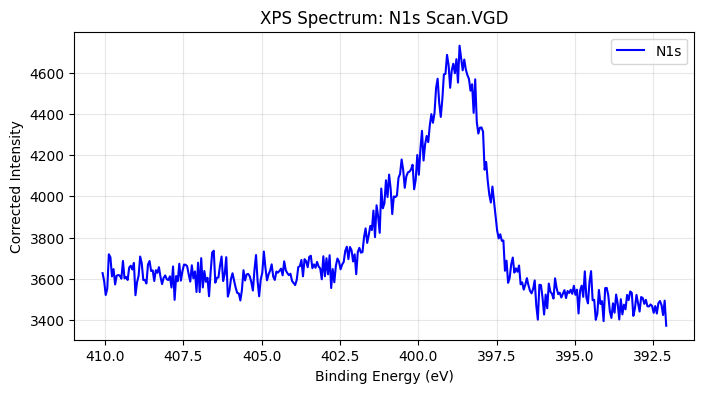


💾 Данные успешно экспортированы в:
   /Users/kirillverbilo/Library/CloudStorage/OneDrive-Личная/Documents_working_dir/2026/Ag-PVT/xps/N1s Scan_20260806_143412.xlsx


In [5]:
# ячейка 4 - импорт файлов
import tkinter as tk
from tkinter import filedialog
import os
from datetime import datetime

def select_and_parse_vgd():
    # 1. Создаем временное корневое окно Tkinter
    root = tk.Tk()
    root.withdraw()
    
    # 2. КРИТИЧЕСКИ ВАЖНО для macOS + Jupyter
    root.attributes('-topmost', True)
    root.update()
    
    # 3. Открываем нативное диалоговое окно выбора файла
    file_path = filedialog.askopenfilename(
        title="Выберите файл VGD для анализа",
        filetypes=[
            ("Файлы Thermo Scientific VGD", "*.vgd"),
            ("Все файлы", "*.*")
        ]
    )
    
    # 4. Сразу уничтожаем окно Tkinter
    root.destroy()
    
    if not file_path:
        print("⚠️ Выбор файла отменен.")
        return
        
    print(f"✅ Выбран файл: {file_path}\n")
    
    try:
        data = read_vgd(file_path)
        
        print("--- Информация о спектре ---")
        print(f"Core Level: {data.core_level}")
        print(f"Количество спектров: {data.num_spectra}")
        print(f"Энергия источника: {data.acquisition.source_energy} эВ")
        print(f"Энергия пропускания (Pass Energy): {data.acquisition.pass_energy} эВ")
        print(f"Точек в данных: {len(data.binding_energy)}")
        
        # Визуализация спектра
        try:
            import matplotlib.pyplot as plt
            
            plt.figure(figsize=(8, 4))
            plt.plot(data.binding_energy, data.corrected_intensity, label=data.core_level, color='blue')
            plt.xlabel("Binding Energy (eV)")
            plt.ylabel("Corrected Intensity")
            plt.gca().invert_xaxis()
            plt.title(f"XPS Spectrum: {os.path.basename(file_path)}")
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.show()
            
        except ImportError:
            print("\n💡 Совет: установите matplotlib (pip install matplotlib)")
        
        # 🕐 ЭКСПОРТ В EXCEL С ТЕГОМ ВРЕМЕНИ И ДАТЫ
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        base_name = os.path.splitext(file_path)[0]
        excel_path = f"{base_name}_{timestamp}.xlsx"
        data.to_excel(excel_path, include_metadata=True)
        print(f"\n💾 Данные успешно экспортированы в:\n   {excel_path}")
        
    except Exception as e:
        print(f"❌ Ошибка при чтении или обработке файла:\n{e}")

# Запуск функции
select_and_parse_vgd()

In [2]:
#ячейка 5- база данных энергий
# ============================================================
# БАЗА ДАННЫХ ЭНЕРГИЙ СВЯЗИ ДЛЯ РАЗНЫХ CORE LEVELS
# Отсортирована по типам химических связей для удобства
# ============================================================

KNOWN_PEAKS = {
    'C1s': [
        # ─── Углеводороды (C-C, C-H) ───
        ('🟢C-C / C-H', 284.80),
        ('🟢Aromatic C', 284.46),
        ('🟢 C=C', 284.53),
        ('🟢C-Si', 284.13),
        
        # ─── Связи с азотом ───
        ('🔵 C-N', 285.74),
        ('🔵 C-N+', 285.91),
        ('🔵 C-NO2', 285.56),
        ('🔵 C*-C≡N', 286.21),
        ('🔵 C*-C≡N (alt)', 286.54),
        ('🔵 C-ONO2', 287.42),
        ('🔵 N-C-O', 287.58),
        ('🔵 N-C=O', 287.91),
        ('🔵 O-C-N-C=O', 288.35),
        ('🔵 N-(C=O)-N', 288.64),
        ('🔵 N-(C=O)-O', 289.40),
        
        # ─── Связи с кислородом ───
        ('🟡 C-O-C', 286.25),
        ('🟡 C-OH', 286.35),
        ('🟡 C*-O-(C=O)', 286.44),
        ('🟡 Epoxide', 286.82),
        ('🟡 C=O', 287.70),
        ('🟡 O-C-O', 287.73),
        ('🟡 C-O-(C*=O)', 288.79),
        ('🟡 HO-(C=O)', 289.06),
        ('🟡 O-(C=O)-O', 289.12),
        ('🟡 -(C=O)-O-(C=O)-', 289.21),
        ('🟡 -O-(C=O)-O-', 290.20),
        
        # ─── Связи с серой ───
        ('🟠 C-S', 285.17),
        ('🟠 C-SO2', 285.18),
        ('🟠 C-SO3-', 284.96),
        
        # ─── Связи с галогенами ───
        ('🔴 C-F', 287.71),
        ('🔴 CF2', 290.70),
        ('🔴 CF3', 292.49),
        ('🔴 C-Cl', 286.82),
        ('🔴 C-Cl (aromatic)', 285.82),
        ('🔴 CCl2', 288.36),
        ('🔴 C-Br', 285.54),
    ],
    'O1s': [
        ('🟢 Metal-O', 530.0),
        ('🟡 C-O / OH', 531.5),
        ('🟡 C=O / adsorbed', 532.5),
    ],
    'N1s': [
        ('🔵 Pyridinic-N', 398.5),
        ('🔵 Pyrrolic-N', 400.0),
        ('🔵 Graphitic-N', 401.3),
        ('🔵 Oxidized-N', 402.5),
        ('🔵 Melanine-N-center', 398.4),
        ('🔵 Melanine-NH-bridge', 399.0),
        ('🔵 Melanine-NH2-free', 400.2),
        ('🔵 Melanine-N-hetero', 401.2),
    ],
    'Ag3d': [
        ('🟢 Ag3d5/2', 368.2),
        ('🟢 Ag3d3/2', 374.2),
    ],
    'Sr3d': [
        ('🟢 Sr3d5/2', 133.5),
        ('🟢 Sr3d3/2', 135.5),
    ],
}

print("✅ База данных KNOWN_PEAKS загружена.")
print(f"   Доступные core levels: {list(KNOWN_PEAKS.keys())}")
print(f"   Всего связей в C1s: {len(KNOWN_PEAKS.get('C1s', []))}")

✅ База данных KNOWN_PEAKS загружена.
   Доступные core levels: ['C1s', 'O1s', 'N1s', 'Ag3d', 'Sr3d']
   Всего связей в C1s: 36


In [3]:
#ячейка 6 - деконволютор
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import savgol_filter, medfilt
from scipy.ndimage import uniform_filter1d
from scipy.signal import find_peaks
import lmfit
from lmfit.models import GaussianModel, PseudoVoigtModel
from IPython.display import display, clear_output
import ipywidgets as widgets
import time
import traceback
from datetime import datetime

try:
    import openpyxl
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "openpyxl"])
    import openpyxl


# ============================================================
# ВСПОМОГАТЕЛЬНЫЕ ФУНКЦИИ
# ============================================================

def remove_noise(intensity, method='median', window_size=5):
    if method == 'none' or window_size < 3:
        return intensity.copy()
    window = window_size if window_size % 2 != 0 else window_size + 1
    window = min(window, len(intensity) - 1)
    if method == 'median':
        return medfilt(intensity, kernel_size=window)
    elif method == 'moving_average':
        return uniform_filter1d(intensity, size=window, mode='nearest')
    elif method == 'savgol':
        return savgol_filter(intensity, window_length=window, polyorder=3)
    return intensity.copy()


def correct_baseline(be, intensity, method='linear', poly_degree=2, edge_points=10):
    if method == 'none':
        return intensity.copy(), None
    if method == 'linear':
        baseline = np.linspace(intensity[0], intensity[-1], len(intensity))
        return intensity - baseline, baseline
    elif method == 'polynomial':
        edge_indices = np.concatenate([
            np.arange(edge_points),
            np.arange(len(intensity) - edge_points, len(intensity))
        ])
        coeffs = np.polyfit(be[edge_indices], intensity[edge_indices], poly_degree)
        baseline = np.polyval(coeffs, be)
        return intensity - baseline, baseline
    return intensity.copy(), None


def perform_deconvolution(be, intensity, peak_configs, 
                          noise_method='median', noise_window=5,
                          baseline_method='none', baseline_poly_degree=2,
                          use_voigt=True, progress_bar=None, status_label=None):
    logs = []
    def log(msg):
        logs.append(msg)
        if status_label is not None:
            status_label.value = f"<b>⏳ {msg}</b>"
    def set_progress(value, desc):
        if progress_bar is not None:
            progress_bar.value = value
        if status_label is not None:
            status_label.value = f"<b>⏳ {desc}</b>"
    
    try:
        set_progress(10, "Этап 1/5: Проверка данных...")
        if not peak_configs:
            return None, None, None, None, "❌ Не выбрано ни одного пика"
        
        set_progress(25, "Этап 2/5: Удаление шума...")
        processed = remove_noise(intensity, method=noise_method, window_size=noise_window)
        
        set_progress(40, "Этап 3/5: Коррекция базовой линии...")
        baseline_corrected, baseline = correct_baseline(
            be, processed, method=baseline_method, poly_degree=baseline_poly_degree
        )
        
        set_progress(55, "Этап 4/5: Подбор параметров...")
        ModelClass = PseudoVoigtModel if use_voigt else GaussianModel
        model = None
        for i, config in enumerate(peak_configs):
            prefix = f'p{i}_'
            peak_model = ModelClass(prefix=prefix)
            model = peak_model if model is None else model + peak_model
        
        params = model.make_params()
        sample_prefix = 'p0_'
        has_height = f'{sample_prefix}height' in params
        intensity_param_name = 'height' if has_height else 'amplitude'
        
        for i, config in enumerate(peak_configs):
            prefix = f'p{i}_'
            center_guess = config['center']
            tolerance = config.get('tolerance')
            height_guess = np.max(baseline_corrected) * 0.5
            
            if tolerance is not None and tolerance > 0:
                # Допуск задан — пик может двигаться в пределах ±tolerance
                params[f'{prefix}center'].set(value=center_guess, 
                                              min=center_guess - tolerance, 
                                              max=center_guess + tolerance,
                                              vary=True)
            else:
                # Допуск = 0 — ЖЁСТКАЯ фиксация позиции пика
                # ВАЖНО: не устанавливаем min и max, только vary=False
                params[f'{prefix}center'].set(value=center_guess, vary=False)
            
            if intensity_param_name == 'height':
                params[f'{prefix}height'].set(value=height_guess, min=0)
            else:
                params[f'{prefix}amplitude'].set(value=height_guess * 2.5, min=0)
            
            params[f'{prefix}sigma'].set(value=1.0, min=0.1, max=5.0)
            if f'{prefix}fraction' in params:
                params[f'{prefix}fraction'].set(value=0.5, min=0, max=1)
        
        set_progress(70, "Этап 4/5: Выполнение подбора (lmfit)...")
        fit_start = time.time()
        result = model.fit(baseline_corrected, params, x=be)
        fit_time = time.time() - fit_start
        
        set_progress(85, "Этап 5/5: Извлечение результатов и статистики...")
        
        peak_data = []
        total_area = 0
        for i, config in enumerate(peak_configs):
            prefix = f'p{i}_'
            p = result.params
            
            center = p[f'{prefix}center'].value
            center_err = p[f'{prefix}center'].stderr if p[f'{prefix}center'].stderr is not None else 0.0
            
            if f'{prefix}height' in p:
                height = p[f'{prefix}height'].value
                height_err = p[f'{prefix}height'].stderr if p[f'{prefix}height'].stderr is not None else 0.0
            else:
                amplitude = p[f'{prefix}amplitude'].value
                sigma = p[f'{prefix}sigma'].value
                height = amplitude / (sigma * np.sqrt(2 * np.pi))
                height_err = 0.0
            
            sigma = p[f'{prefix}sigma'].value
            sigma_err = p[f'{prefix}sigma'].stderr if p[f'{prefix}sigma'].stderr is not None else 0.0
            fwhm = p[f'{prefix}fwhm'].value
            
            if f'{prefix}amplitude' in p:
                area = p[f'{prefix}amplitude'].value
                area_err = p[f'{prefix}amplitude'].stderr if p[f'{prefix}amplitude'].stderr is not None else 0.0
            else:
                area = p[f'{prefix}height'].value * p[f'{prefix}sigma'].value * np.sqrt(2 * np.pi)
                area_err = 0.0
            
            variance = sigma ** 2
            variance_err = 2 * sigma * sigma_err
            cv = (sigma_err / sigma * 100) if sigma > 0 else 0.0
            ci_95 = 1.96 * sigma_err
            
            total_area += area
            peak_data.append({
                'Пик': config['name'],
                'Положение (эВ)': round(center, 3),
                'Ошибка положения': round(center_err, 4),
                'Высота': round(height, 3),
                'Ошибка высоты': round(height_err, 4),
                'Sigma (эВ)': round(sigma, 3),
                'Ошибка sigma': round(sigma_err, 4),
                'Дисперсия (σ²)': round(variance, 4),
                'Ошибка дисперсии': round(variance_err, 4),
                'FWHM (эВ)': round(fwhm, 3),
                'Площадь': round(area, 3),
                'Ошибка площади': round(area_err, 4),
                'CV sigma (%)': round(cv, 2),
                '95% CI sigma': round(ci_95, 4),
            })
        
        df_peaks = pd.DataFrame(peak_data)
        df_peaks['% от общей'] = (df_peaks['Площадь'] / total_area * 100).round(2)
        
        residuals = result.residual
        rmse = np.sqrt(np.mean(residuals**2))
        ss_res = np.sum(residuals**2)
        ss_tot = np.sum((baseline_corrected - np.mean(baseline_corrected))**2)
        r_squared = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0
        
        metrics = {
            'chi_square': result.redchi,
            'rmse': rmse,
            'r_squared': r_squared,
            'total_area': total_area,
            'n_iterations': result.nfev,
            'fit_time': fit_time,
            'success': result.success,
            'message': result.message,
        }
        
        set_progress(100, "✅ Готово!")
        return baseline_corrected, baseline, result, df_peaks, metrics
    
    except Exception as e:
        return None, None, None, None, f"❌ Ошибка: {str(e)}\n{traceback.format_exc()}"


def analyze_spectrum_suggestions(be, intensity, core_level="Unknown", prominence=0.05):
    """
    Первичный анализ спектра: находит локальные максимумы и предлагает 
    наиболее подходящие связи из KNOWN_PEAKS.
    """
    if core_level not in KNOWN_PEAKS:
        return f"⚠️ Нет базы данных для core level '{core_level}'"
    
    # Сглаживаем для поиска пиков
    window = 15 if 15 % 2 != 0 else 16
    window = min(window, len(be) - 1)
    smoothed = savgol_filter(intensity, window_length=window, polyorder=3)
    
    # Находим пики
    peak_indices, properties = find_peaks(smoothed, prominence=np.max(smoothed) * prominence)
    
    if len(peak_indices) == 0:
        return "⚠️ Пики не найдены. Попробуйте уменьшить prominence."
    
    known = KNOWN_PEAKS[core_level]
    
    suggestions = []
    for idx in peak_indices:
        be_peak = be[idx]
        intensity_peak = smoothed[idx]
        
        # Находим ближайшую известную связь
        best_match = None
        best_diff = float('inf')
        for name, ref_be in known:
            diff = abs(be_peak - ref_be)
            if diff < best_diff:
                best_diff = diff
                best_match = (name, ref_be)
        
        suggestions.append({
            'BE пика (эВ)': round(be_peak, 2),
            'Интенсивность': round(intensity_peak, 2),
            'Наиболее вероятная связь': best_match[0],
            'Справочное BE (эВ)': best_match[1],
            'Разница (эВ)': round(best_diff, 2),
            'Совпадение': '✅ Отличное' if best_diff < 0.3 else ('⚠️ Среднее' if best_diff < 0.7 else '❌ Слабое')
        })
    
    return suggestions


# ============================================================
# ОСНОВНАЯ ФУНКЦИЯ ИНСТРУМЕНТА
# ============================================================

def interactive_peak_fitting_advanced(be, intensity, core_level="Unknown"):
    print("=" * 60)
    print("🎛️ ИНТЕРАКТИВНЫЙ ИНСТРУМЕНТ АНАЛИЗА XPS СПЕКТРОВ")
    print("=" * 60)
    print(f"📊 Анализ спектра: {core_level}")
    print(f"   • Точек: {len(be)}, диапазон: {be.min():.2f}-{be.max():.2f} эВ")
    
    known_peaks = KNOWN_PEAKS.get(core_level, [])
    
    # ============================================================
    # 1. НАСТРОЙКИ УДАЛЕНИЯ ШУМА
    # ============================================================
    noise_disable_checkbox = widgets.Checkbox(value=False, description='Отключить удаление шума')
    noise_method_dropdown = widgets.Dropdown(
        options=[
            ('Медианный фильтр (рекомендуется)', 'median'),
            ('Скользящее среднее', 'moving_average'),
            ('Савицкий-Голей', 'savgol'),
            ('Без обработки', 'none')
        ],
        value='median', description='Метод:', layout=widgets.Layout(width='400px')
    )
    noise_window_text = widgets.BoundedIntText(
        value=5, min=3, max=51, step=2, description='Окно:', layout=widgets.Layout(width='200px')
    )
    
    # ============================================================
    # 2. НАСТРОЙКИ БАЗОВОЙ ЛИНИИ
    # ============================================================
    baseline_disable_checkbox = widgets.Checkbox(value=False, description='Отключить коррекцию базовой линии')
    baseline_method_dropdown = widgets.Dropdown(
        options=[
            ('Линейная (рекомендуется)', 'linear'),
            ('Полиномиальная', 'polynomial'),
            ('Без коррекции', 'none')
        ],
        value='linear', description='Метод:', layout=widgets.Layout(width='400px')
    )
    baseline_poly_degree_text = widgets.BoundedIntText(
        value=2, min=1, max=5, step=1, description='Степень полинома:', layout=widgets.Layout(width='200px')
    )
    
    # ============================================================
    # 3. НАСТРОЙКИ ПИКОВ (все галочки СНЯТЫ по умолчанию)
    # ============================================================
    peak_widgets = []
    for name, position in known_peaks:
        cb_width = max(280, len(name) * 9 + 40)
        # ВАЖНО: value=False — все галочки сняты по умолчанию
        checkbox = widgets.Checkbox(value=False, description=name, layout=widgets.Layout(width=f'{cb_width}px'))
        position_text = widgets.FloatText(
            value=position, step=0.01, description='Позиция (эВ):', layout=widgets.Layout(width='200px')
        )
        tolerance_text = widgets.FloatText(
            value=0.0, step=0.1, description='Допуск (эВ):', layout=widgets.Layout(width='200px')
        )
        disable_tolerance_checkbox = widgets.Checkbox(
            value=False, description='Без ограничений', layout=widgets.Layout(width='180px')
        )
        show_on_plot_checkbox = widgets.Checkbox(
            value=True, description='📈 На графике', layout=widgets.Layout(width='150px')
        )
        
        peak_widgets.append({
            'name': name,
            'checkbox': checkbox,
            'position': position_text,
            'tolerance': tolerance_text,
            'disable_tolerance': disable_tolerance_checkbox,
            'show_on_plot': show_on_plot_checkbox
        })
    
    # ============================================================
    # 4. ДОБАВЛЕНИЕ СВОИХ ПИКОВ
    # ============================================================
    custom_name = widgets.Text(description='Название:', placeholder='C-F', layout=widgets.Layout(width='280px'))
    custom_pos = widgets.FloatText(description='Позиция (эВ):', value=285.0, step=0.01, layout=widgets.Layout(width='200px'))
    custom_tol = widgets.FloatText(description='Допуск (эВ):', value=0.0, step=0.1, layout=widgets.Layout(width='200px'))
    add_btn = widgets.Button(description='➕ Добавить', button_style='info')
    
    custom_peak_widgets = []
    custom_container = widgets.VBox([])
    add_status = widgets.HTML(value="")
    
    def on_add_clicked(b):
        if custom_name.value.strip() and custom_pos.value:
            cb_width = max(280, len(custom_name.value) * 9 + 40)
            checkbox = widgets.Checkbox(value=True, description=custom_name.value, layout=widgets.Layout(width=f'{cb_width}px'))
            position_text = widgets.FloatText(
                value=custom_pos.value, step=0.01, description='Позиция (эВ):', layout=widgets.Layout(width='200px')
            )
            tolerance_text = widgets.FloatText(
                value=custom_tol.value, step=0.1, description='Допуск (эВ):', layout=widgets.Layout(width='200px')
            )
            disable_tolerance_checkbox = widgets.Checkbox(
                value=False, description='Без ограничений', layout=widgets.Layout(width='180px')
            )
            show_on_plot_checkbox = widgets.Checkbox(
                value=True, description=' На графике', layout=widgets.Layout(width='150px')
            )
            
            widget_dict = {
                'name': custom_name.value,
                'checkbox': checkbox,
                'position': position_text,
                'tolerance': tolerance_text,
                'disable_tolerance': disable_tolerance_checkbox,
                'show_on_plot': show_on_plot_checkbox
            }
            custom_peak_widgets.append(widget_dict)
            
            peak_row = widgets.HBox([checkbox, position_text, tolerance_text, disable_tolerance_checkbox, show_on_plot_checkbox])
            custom_container.children = list(custom_container.children) + [peak_row]
            
            add_status.value = f"<b style='color:green'>✅ Добавлен: {custom_name.value}</b>"
            custom_name.value = ''
        else:
            add_status.value = "<b style='color:red'>⚠️ Укажите название и позицию</b>"
    
    add_btn.on_click(on_add_clicked)
    
    # ============================================================
    # 5. ПРОФИЛЬ ПИКА
    # ============================================================
    profile_dropdown = widgets.Dropdown(
        options=[('Псевдо-Войт (рекомендуется)', True), ('Гаусс', False)],
        value=True, description='Профиль пика:', layout=widgets.Layout(width='400px')
    )
    
    # ============================================================
    # 6. НАСТРОЙКИ ОТОБРАЖЕНИЯ ГРАФИКА + ОТЗЕРКАЛИВАНИЕ
    # ============================================================
    show_raw_checkbox = widgets.Checkbox(value=True, description='Исходные данные (точки)')
    raw_color = widgets.ColorPicker(concise=False, description='Цвет:', value='#000000', layout=widgets.Layout(width='180px'))
    raw_alpha = widgets.FloatSlider(value=0.4, min=0.0, max=1.0, step=0.05, description='α:', layout=widgets.Layout(width='200px'))
    
    show_smoothed_checkbox = widgets.Checkbox(value=True, description='Сглаженные данные')
    smoothed_color = widgets.ColorPicker(concise=False, description='Цвет:', value='#00AA00', layout=widgets.Layout(width='180px'))
    smoothed_alpha = widgets.FloatSlider(value=0.8, min=0.0, max=1.0, step=0.05, description='α:', layout=widgets.Layout(width='200px'))
    smoothed_fill = widgets.Checkbox(value=False, description='Закрасить площадь')
    smoothed_fill_alpha = widgets.FloatSlider(value=0.2, min=0.0, max=1.0, step=0.05, description='α заливки:', layout=widgets.Layout(width='200px'))
    
    show_baseline_checkbox = widgets.Checkbox(value=True, description='Базовая линия')
    baseline_color = widgets.ColorPicker(concise=False, description='Цвет:', value='#008800', layout=widgets.Layout(width='180px'))
    
    show_total_fit_checkbox = widgets.Checkbox(value=True, description='Общая аппроксимация')
    total_fit_color = widgets.ColorPicker(concise=False, description='Цвет:', value='#FF0000', layout=widgets.Layout(width='180px'))
    total_fit_alpha = widgets.FloatSlider(value=1.0, min=0.0, max=1.0, step=0.05, description='α:', layout=widgets.Layout(width='200px'))
    total_fit_fill = widgets.Checkbox(value=False, description='Закрасить площадь')
    total_fit_fill_alpha = widgets.FloatSlider(value=0.15, min=0.0, max=1.0, step=0.05, description='α заливки:', layout=widgets.Layout(width='200px'))
    
    show_components_checkbox = widgets.Checkbox(value=True, description='Отдельные компоненты (пики)')
    
    # ОТЗЕРКАЛИВАНИЕ ОСЕЙ
    invert_x_checkbox = widgets.Checkbox(value=True, description='Инвертировать ось X (классический XPS: BE уменьшается →)')
    invert_y_checkbox = widgets.Checkbox(value=False, description='Инвертировать ось Y')
    
    # ============================================================
    # 7. ГРАНИЦЫ ГРАФИКА
    # ============================================================
    x_min_text = widgets.FloatText(value=be.min(), step=0.1, description='X min (эВ):', layout=widgets.Layout(width='200px'))
    x_max_text = widgets.FloatText(value=be.max(), step=0.1, description='X max (эВ):', layout=widgets.Layout(width='200px'))
    y_min_text = widgets.FloatText(value=0.0, step=10, description='Y min:', layout=widgets.Layout(width='200px'))
    y_max_text = widgets.FloatText(value=np.max(intensity) * 1.1, step=10, description='Y max:', layout=widgets.Layout(width='200px'))
    auto_scale_checkbox = widgets.Checkbox(value=True, description='Автомасштаб')
    
    # ============================================================
    # 8. ДИНАМИЧЕСКИЕ НАСТРОЙКИ ЦВЕТОВ ПИКОВ (под графиком)
    # ============================================================
    peak_color_container = widgets.VBox([])
    update_colors_btn = widgets.Button(
        description='🔄 Обновить список пиков для настройки цветов',
        button_style='info',
        layout=widgets.Layout(width='400px')
    )
    
    def update_peak_color_controls():
        """Пересоздаёт виджеты цветов только для выбранных пиков."""
        all_selected = []
        for pw in peak_widgets + custom_peak_widgets:
            if pw['checkbox'].value:
                all_selected.append(pw)
        
        if not all_selected:
            peak_color_container.children = [widgets.HTML("<i>Нет выбранных пиков. Отметьте галочками нужные пики выше.</i>")]
            return
        
        rows = []
        for pw in all_selected:
            # Если виджет цвета уже был создан — используем его, иначе создаём новый
            if 'color_widget' not in pw:
                pw['color_widget'] = widgets.ColorPicker(
                    concise=False, description='Цвет:', 
                    value='#' + ''.join(np.random.choice(list('0123456789ABCDEF'), 6)),
                    layout=widgets.Layout(width='180px')
                )
                pw['fill_widget'] = widgets.Checkbox(value=False, description='Закрасить', layout=widgets.Layout(width='120px'))
                pw['fill_alpha_widget'] = widgets.FloatSlider(value=0.3, min=0.0, max=1.0, step=0.05, description='α:', layout=widgets.Layout(width='200px'))
            
            row = widgets.HBox([
                widgets.HTML(f"<b>{pw['name']}</b>", layout=widgets.Layout(width='200px')),
                pw['color_widget'],
                pw['fill_widget'],
                pw['fill_alpha_widget']
            ])
            rows.append(row)
        
        peak_color_container.children = rows
    
    def on_update_colors_clicked(b):
        update_peak_color_controls()
    
    update_colors_btn.on_click(on_update_colors_clicked)
    
    # ============================================================
    # 9. ОБЛАСТИ ВЫВОДА
    # ============================================================
    fig_output = widgets.Output()
    table_output = widgets.Output()
    metrics_output = widgets.Output()
    suggestions_output = widgets.Output()
    
    # ============================================================
    # 10. ИНДИКАТОР ПРОГРЕССА
    # ============================================================
    progress_bar = widgets.IntProgress(
        value=0, min=0, max=100, 
        description='Прогресс:', 
        bar_style='info',
        layout=widgets.Layout(width='100%', height='30px')
    )
    status_label = widgets.HTML(value="<i>⏸️ Ожидание запуска...</i>")
    
    # ============================================================
    # 11. КНОПКИ
    # ============================================================
    analyze_btn = widgets.Button(
        description='🔍 Первичный анализ спектра (предложить пики)',
        button_style='primary',
        layout=widgets.Layout(width='450px', height='45px', font_size='14px')
    )
    
    fit_btn = widgets.Button(
        description=' Выполнить деконволюцию', 
        button_style='success',
        layout=widgets.Layout(width='350px', height='45px', font_size='16px')
    )
    
    # Хранилище результатов
    last_results = {'be': be, 'intensity': intensity, 'baseline_corrected': None, 'baseline': None, 
                    'result': None, 'df_peaks': None, 'metrics': None, 'peak_configs': None,
                    'noise_method': None, 'noise_window': None, 'baseline_method': None}
    
    # ============================================================
    # ФУНКЦИЯ ПОСТРОЕНИЯ ГРАФИКА
    # ============================================================
    def build_plot(baseline_corrected, baseline, result, df_peaks, peak_configs,
                   show_raw, show_smoothed, show_baseline, show_total_fit, show_components,
                   noise_disable, noise_method, noise_window,
                   baseline_disable, baseline_method,
                   raw_color_val, raw_alpha_val,
                   smoothed_color_val, smoothed_alpha_val, smoothed_fill_val, smoothed_fill_alpha_val,
                   baseline_color_val,
                   total_fit_color_val, total_fit_alpha_val, total_fit_fill_val, total_fit_fill_alpha_val,
                   invert_x, invert_y,
                   x_min, x_max, y_min, y_max, auto_scale):
        
        fig, ax = plt.subplots(figsize=(14, 7))
        
        if show_raw:
            ax.plot(be, intensity, '.', color=raw_color_val, label='Исходные данные', 
                    alpha=raw_alpha_val, markersize=3)
        
        if show_baseline and baseline is not None and not baseline_disable:
            ax.plot(be, baseline, '--', color=baseline_color_val, 
                   label=f'Базовая линия ({baseline_method})', linewidth=2, alpha=0.8)
        
        if show_smoothed and (not noise_disable or not baseline_disable):
            ax.plot(be, baseline_corrected, '-', color=smoothed_color_val, 
                   label='После обработки', linewidth=1.8, alpha=smoothed_alpha_val)
            if smoothed_fill_val:
                ax.fill_between(be, 0, baseline_corrected, color=smoothed_color_val, 
                               alpha=smoothed_fill_alpha_val, label='Заливка обработки')
        
        if show_total_fit and result is not None:
            ax.plot(be, result.best_fit, '-', color=total_fit_color_val, 
                   label='Общая аппроксимация', linewidth=2.5, alpha=total_fit_alpha_val)
            if total_fit_fill_val:
                ax.fill_between(be, 0, result.best_fit, color=total_fit_color_val, 
                               alpha=total_fit_fill_alpha_val, label='Заливка аппроксимации')
        
        if show_components and result is not None:
            components = result.eval_components(x=be, params=result.params)
            
            for i, config in enumerate(peak_configs):
                if not config.get('show_on_plot', True):
                    continue
                
                prefix = f'p{i}_'
                peak_color = config.get('color', '#1f77b4')
                ax.plot(be, components[f'{prefix}'], '--', color=peak_color, 
                       label=f'{config["name"]} ({df_peaks.iloc[i]["Положение (эВ)"]} эВ)',
                       linewidth=2)
                
                if config.get('fill', False):
                    fill_alpha = config.get('fill_alpha', 0.3)
                    ax.fill_between(be, 0, components[f'{prefix}'], color=peak_color, 
                                   alpha=fill_alpha)
        
        # ОТЗЕРКАЛИВАНИЕ ОСЕЙ
        if invert_x:
            ax.invert_xaxis()
        if invert_y:
            ax.invert_yaxis()
        
        ax.set_xlabel('Энергия связи (Binding Energy, eV)', fontsize=12)
        ax.set_ylabel('Интенсивность (Intensity)', fontsize=12)
        ax.set_title(f'Деконволюция спектра: {core_level}', fontsize=14, fontweight='bold')
        ax.legend(loc='upper right', fontsize=9)
        ax.grid(True, alpha=0.3)
        
        if not auto_scale:
            if invert_x:
                ax.set_xlim(x_max, x_min)
            else:
                ax.set_xlim(x_min, x_max)
            ax.set_ylim(y_min, y_max)
        
        plt.tight_layout()
        plt.show()
        return fig
    
    # ============================================================
    # ПЕРВИЧНЫЙ АНАЛИЗ СПЕКТРА
    # ============================================================
    def on_analyze_clicked(b):
        analyze_btn.disabled = True
        analyze_btn.description = '⏳ Анализирую...'
        suggestions_output.clear_output(wait=True)
        
        try:
            with suggestions_output:
                print("🔍 Выполняю первичный анализ спектра...")
                print(f"   Core level: {core_level}")
                print()
                
                suggestions = analyze_spectrum_suggestions(be, intensity, core_level, prominence=0.05)
                
                if isinstance(suggestions, str):
                    print(suggestions)
                else:
                    print(f"✅ Найдено {len(suggestions)} локальных максимумов.")
                    print(f"   Для каждого пика предложена наиболее подходящая связь из базы данных.\n")
                    
                    df_suggestions = pd.DataFrame(suggestions)
                    styled = df_suggestions.style.set_properties(**{'text-align': 'center'}) \
                                           .set_table_styles([dict(selector='th', props=[('text-align', 'center')])])
                    display(styled)
                    
                    print("\n💡 Рекомендации:")
                    print("   • Пики с разницей < 0.3 эВ — отличное совпадение, можно использовать")
                    print("   • Пики с разницей 0.3-0.7 эВ — среднее совпадение, проверьте контекст")
                    print("   • Пики с разницей > 0.7 эВ — слабое совпадение, возможно другой тип связи")
                    print("\n👉 Отметьте галочками предложенные пики в списке выше и нажмите '🔬 Выполнить деконволюцию'")
        except Exception as e:
            with suggestions_output:
                print(f"❌ Ошибка анализа: {e}")
                traceback.print_exc()
        finally:
            analyze_btn.disabled = False
            analyze_btn.description = '🔍 Первичный анализ спектра (предложить пики)'
    
    analyze_btn.on_click(on_analyze_clicked)
    
    # ============================================================
    # ДЕКОНВОЛЮЦИЯ
    # ============================================================
    def on_fit_clicked(b):
        fit_btn.disabled = True
        fit_btn.description = '⏳ Выполняется...'
        fit_btn.button_style = 'warning'
        
        fig_output.clear_output(wait=True)
        table_output.clear_output(wait=True)
        metrics_output.clear_output(wait=True)
        progress_bar.value = 0
        progress_bar.bar_style = 'info'
        
        peak_configs = []
        all_peak_widgets = peak_widgets + custom_peak_widgets
        
        for pw in all_peak_widgets:
            if pw['checkbox'].value:
                tolerance = None if pw['disable_tolerance'].value else pw['tolerance'].value
                # Получаем цвет из динамических виджетов, если они есть
                color = pw.get('color_widget', widgets.ColorPicker()).value if 'color_widget' in pw else '#1f77b4'
                fill = pw.get('fill_widget', widgets.Checkbox()).value if 'fill_widget' in pw else False
                fill_alpha = pw.get('fill_alpha_widget', widgets.FloatSlider()).value if 'fill_alpha_widget' in pw else 0.3
                
                peak_configs.append({
                    'name': pw['name'],
                    'center': pw['position'].value,
                    'tolerance': tolerance,
                    'show_on_plot': pw['show_on_plot'].value,
                    'color': color,
                    'fill': fill,
                    'fill_alpha': fill_alpha
                })
        
        if not peak_configs:
            status_label.value = "<b style='color:red'>❌ Не выбрано ни одного пика!</b>"
            progress_bar.bar_style = 'danger'
            fit_btn.disabled = False
            fit_btn.description = '🔬 Выполнить деконволюцию'
            fit_btn.button_style = 'success'
            return
        
        noise_disable = noise_disable_checkbox.value
        noise_method = noise_method_dropdown.value
        noise_window = noise_window_text.value
        baseline_disable = baseline_disable_checkbox.value
        baseline_method = baseline_method_dropdown.value
        baseline_poly_degree = baseline_poly_degree_text.value
        use_voigt = profile_dropdown.value
        
        show_raw = show_raw_checkbox.value
        show_smoothed = show_smoothed_checkbox.value
        show_baseline = show_baseline_checkbox.value
        show_total_fit = show_total_fit_checkbox.value
        show_components = show_components_checkbox.value
        invert_x = invert_x_checkbox.value
        invert_y = invert_y_checkbox.value
        
        actual_noise_method = 'none' if noise_disable else noise_method
        actual_baseline_method = 'none' if baseline_disable else baseline_method
        
        status_label.value = "<b> Запуск деконволюции...</b>"
        
        result_data = perform_deconvolution(
            be, intensity, peak_configs,
            noise_method=actual_noise_method,
            noise_window=noise_window,
            baseline_method=actual_baseline_method,
            baseline_poly_degree=baseline_poly_degree,
            use_voigt=use_voigt,
            progress_bar=progress_bar,
            status_label=status_label
        )
        
        if len(result_data) == 5 and isinstance(result_data[4], str):
            baseline_corrected, baseline, result, df_peaks, error_msg = result_data
            with metrics_output:
                print(error_msg)
            progress_bar.bar_style = 'danger'
            status_label.value = "<b style='color:red'>❌ Ошибка выполнения</b>"
        else:
            baseline_corrected, baseline, result, df_peaks, metrics = result_data
            
            last_results.update({
                'baseline_corrected': baseline_corrected,
                'baseline': baseline,
                'result': result,
                'df_peaks': df_peaks,
                'metrics': metrics,
                'peak_configs': peak_configs,
                'noise_method': actual_noise_method,
                'noise_window': noise_window,
                'baseline_method': actual_baseline_method,
            })
            
            with fig_output:
                build_plot(baseline_corrected, baseline, result, df_peaks, peak_configs,
                          show_raw, show_smoothed, show_baseline, show_total_fit, show_components,
                          noise_disable, noise_method, noise_window,
                          baseline_disable, baseline_method,
                          raw_color.value, raw_alpha.value,
                          smoothed_color.value, smoothed_alpha.value, smoothed_fill.value, smoothed_fill_alpha.value,
                          baseline_color.value,
                          total_fit_color.value, total_fit_alpha.value, total_fit_fill.value, total_fit_fill_alpha.value,
                          invert_x, invert_y,
                          x_min_text.value, x_max_text.value, y_min_text.value, y_max_text.value,
                          auto_scale_checkbox.value)
            
            with table_output:
                print("\n📊 Параметры выделенных пиков (со статистикой):")
                styled_table = df_peaks.style.set_properties(**{'text-align': 'center'}) \
                                       .set_table_styles([dict(selector='th', props=[('text-align', 'center')])])
                display(styled_table)
            
            with metrics_output:
                print("\n" + "=" * 60)
                print("📈 МЕТРИКИ КАЧЕСТВА ПОДБОРА")
                print("=" * 60)
                print(f"   • Reduced Chi-square: {metrics['chi_square']:.4f}")
                print(f"   • R-squared: {metrics['r_squared']:.6f}")
                print(f"   • RMSE: {metrics['rmse']:.4f}")
                print(f"   • Суммарная площадь: {metrics['total_area']:.2f}")
                print(f"   • Итераций: {metrics['n_iterations']}")
                print(f"   • Время подбора: {metrics['fit_time']:.2f} сек")
                print("=" * 60)
                
                if metrics['r_squared'] > 0.99:
                    print("✅ Отличное качество подбора (R² > 0.99)")
                    progress_bar.bar_style = 'success'
                elif metrics['r_squared'] > 0.95:
                    print("⚠️ Хорошее качество подбора (R² > 0.95)")
                    progress_bar.bar_style = 'success'
                else:
                    print("❌ Низкое качество подбора. Попробуйте изменить параметры.")
                    progress_bar.bar_style = 'warning'
                
                status_label.value = f"<b style='color:green'>✅ Готово за {metrics['fit_time']:.2f} сек!</b>"
        
        fit_btn.disabled = False
        fit_btn.description = '🔬 Выполнить деконволюцию'
        fit_btn.button_style = 'success'
    
    fit_btn.on_click(on_fit_clicked)
    
    # ============================================================
    # КОМПОНОВКА ИНТЕРФЕЙСА
    # ============================================================
    peak_rows = []
    for pw in peak_widgets:
        peak_row = widgets.HBox([
            pw['checkbox'], pw['position'], pw['tolerance'], pw['disable_tolerance'], pw['show_on_plot']
        ])
        peak_rows.append(peak_row)
    
    noise_box = widgets.VBox([
        widgets.HTML("<h3>🔇 Настройки удаления шума:</h3>"),
        noise_disable_checkbox,
        widgets.HBox([noise_method_dropdown, noise_window_text])
    ])
    
    baseline_box = widgets.VBox([
        widgets.HTML("<h3>📏 Настройки коррекции базовой линии:</h3>"),
        baseline_disable_checkbox,
        widgets.HBox([baseline_method_dropdown, baseline_poly_degree_text])
    ])
    
    peaks_box = widgets.VBox([
        widgets.HTML("<h3>📋 Настройка пиков (все галочки сняты по умолчанию):</h3>"),
        widgets.HTML("<i>Отметьте галочками нужные пики. Допуск по умолчанию 0 эВ (фиксированная позиция).</i>"),
        widgets.HTML("<b>Пик | Позиция (эВ) | Допуск (эВ) | Без ограничений | 📈 На графике</b>"),
    ] + peak_rows)
    
    add_box = widgets.HBox([custom_name, custom_pos, custom_tol, add_btn])
    
    display_box = widgets.VBox([
        widgets.HTML("<h3>👁️ Настройки отображения и цвета:</h3>"),
        widgets.HTML("<b>Исходные данные:</b>"),
        widgets.HBox([show_raw_checkbox, raw_color, raw_alpha]),
        widgets.HTML("<b>Сглаженные данные:</b>"),
        widgets.HBox([show_smoothed_checkbox, smoothed_color, smoothed_alpha, smoothed_fill, smoothed_fill_alpha]),
        widgets.HTML("<b>Базовая линия:</b>"),
        widgets.HBox([show_baseline_checkbox, baseline_color]),
        widgets.HTML("<b>Общая аппроксимация:</b>"),
        widgets.HBox([show_total_fit_checkbox, total_fit_color, total_fit_alpha, total_fit_fill, total_fit_fill_alpha]),
        widgets.HBox([show_components_checkbox]),
        widgets.HTML("<hr>"),
        widgets.HTML("<b>🔄 Отзеркаливание осей:</b>"),
        widgets.HBox([invert_x_checkbox, invert_y_checkbox]),
    ])
    
    bounds_box = widgets.VBox([
        widgets.HTML("<h3>📐 Границы графика:</h3>"),
        auto_scale_checkbox,
        widgets.HBox([x_min_text, x_max_text, y_min_text, y_max_text]),
    ])
    
    profile_box = widgets.VBox([
        widgets.HTML("<h3>️ Профиль пика:</h3>"),
        profile_dropdown
    ])
    
    # Динамические настройки цветов пиков (под графиком)
    peak_colors_box = widgets.VBox([
        widgets.HTML("<h3>🎨 Настройка цветов и заливки для выбранных пиков:</h3>"),
        widgets.HTML("<i>Сначала отметьте галочками нужные пики в списке выше, затем нажмите кнопку обновления.</i>"),
        update_colors_btn,
        widgets.HTML("<br>"),
        peak_color_container
    ])
    
    progress_box = widgets.VBox([
        widgets.HTML("<h3>📊 Статус выполнения:</h3>"),
        progress_bar,
        status_label
    ])

    # ============================================================
    # 12. ЭКСПОРТ ГРАФИКА И EXCEL (ДОБАВЛЕННЫЙ БЛОК)
    # ============================================================
    export_format_dropdown = widgets.Dropdown(
        options=[('PNG', 'png'), ('TIFF', 'tiff'), ('JPEG', 'jpeg'), ('PDF', 'pdf'), ('SVG', 'svg')],
        value='png', description='Формат:', layout=widgets.Layout(width='200px')
    )
    export_quality_slider = widgets.IntSlider(
        value=95, min=10, max=100, step=5, description='Качество (%):', layout=widgets.Layout(width='300px')
    )
    export_dpi_slider = widgets.IntSlider(
        value=300, min=72, max=600, step=50, description='DPI:', layout=widgets.Layout(width='300px')
    )
    export_btn = widgets.Button(description='💾 Экспортировать график', button_style='primary',
                                layout=widgets.Layout(width='300px', height='40px'))
    export_status = widgets.HTML(value="")
    
    export_excel_btn = widgets.Button(description='📊 Экспорт всех данных в Excel', button_style='success',
                                      layout=widgets.Layout(width='350px', height='40px'))
    export_excel_status = widgets.HTML(value="")

    def on_export_clicked(b):
        if last_results['result'] is None:
            export_status.value = "<b style='color:red'>❌ Сначала выполните деконволюцию!</b>"
            return
        try:
            fmt = export_format_dropdown.value
            quality = export_quality_slider.value
            dpi = export_dpi_slider.value
            
            fig, ax = plt.subplots(figsize=(14, 7))
            # (Здесь используется упрощенная перерисовка на основе last_results)
            bc = last_results['baseline_corrected']
            bl = last_results['baseline']
            res = last_results['result']
            dfs = last_results['df_peaks']
            pcs = last_results['peak_configs']
            
            if show_raw_checkbox.value: ax.plot(be, intensity, '.', color=raw_color.value, alpha=raw_alpha.value, markersize=3)
            if show_baseline_checkbox.value and bl is not None and not baseline_disable_checkbox.value:
                ax.plot(be, bl, '--', color=baseline_color.value, linewidth=2, alpha=0.8)
            if show_smoothed_checkbox.value:
                ax.plot(be, bc, '-', color=smoothed_color.value, linewidth=1.8, alpha=smoothed_alpha.value)
                if smoothed_fill.value: ax.fill_between(be, 0, bc, color=smoothed_color.value, alpha=smoothed_fill_alpha.value)
            if show_total_fit_checkbox.value:
                ax.plot(be, res.best_fit, '-', color=total_fit_color.value, linewidth=2.5, alpha=total_fit_alpha.value)
                if total_fit_fill.value: ax.fill_between(be, 0, res.best_fit, color=total_fit_color.value, alpha=total_fit_fill_alpha.value)
            if show_components_checkbox.value:
                comps = res.eval_components(x=be, params=res.params)
                for i, cfg in enumerate(pcs):
                    if not cfg.get('show_on_plot', True): continue
                    pref = f'p{i}_'
                    ax.plot(be, comps[pref], '--', color=cfg.get('color', '#1f77b4'), linewidth=2)
                    if cfg.get('fill', False): ax.fill_between(be, 0, comps[pref], color=cfg.get('color', '#1f77b4'), alpha=cfg.get('fill_alpha', 0.3))
            
            if invert_x_checkbox.value: ax.invert_xaxis()
            if invert_y_checkbox.value: ax.invert_yaxis()
            ax.set_xlabel('Binding Energy (eV)', fontsize=12); ax.set_ylabel('Intensity', fontsize=12)
            ax.set_title(f'XPS Deconvolution: {core_level}', fontsize=14, fontweight='bold')
            ax.legend(loc='upper right', fontsize=9); ax.grid(True, alpha=0.3)
            plt.tight_layout()
            
            timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
            filename = f"xps_{core_level}_{timestamp}.{fmt}"
            save_kwargs = {'dpi': dpi, 'bbox_inches': 'tight'}
            if fmt in ['jpeg', 'jpg']: save_kwargs['quality'] = quality
            elif fmt == 'tiff': save_kwargs['pil_kwargs'] = {'quality': quality}
            
            fig.savefig(filename, **save_kwargs)
            plt.close(fig)
            export_status.value = f"<b style='color:green'>✅ Сохранено: {filename} (DPI={dpi})</b>"
        except Exception as e:
            export_status.value = f"<b style='color:red'>❌ Ошибка экспорта: {e}</b>"

    def on_export_excel_clicked(b):
        if last_results['result'] is None:
            export_excel_status.value = "<b style='color:red'>❌ Сначала выполните деконволюцию!</b>"
            return
        try:
            timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
            filename = f"xps_{core_level}_full_{timestamp}.xlsx"
            with pd.ExcelWriter(filename, engine='openpyxl') as writer:
                pd.DataFrame({'Binding_Energy_eV': be, 'Raw_Intensity': intensity}).to_excel(writer, sheet_name='Raw Data', index=False)
                
                proc = remove_noise(intensity, method=last_results['noise_method'], window_size=last_results['noise_window'])
                pd.DataFrame({'Binding_Energy_eV': be, 'After_Noise_Removal': proc}).to_excel(writer, sheet_name='After Noise Removal', index=False)
                
                bc, bl = correct_baseline(be, proc, method=last_results['baseline_method'], poly_degree=baseline_poly_degree_text.value)
                pd.DataFrame({'Binding_Energy_eV': be, 'Baseline': bl if bl is not None else [0]*len(be), 'After_Baseline_Correction': bc}).to_excel(writer, sheet_name='Baseline Correction', index=False)
                
                res = last_results['result']
                comps = res.eval_components(x=be, params=res.params)
                df_dec = pd.DataFrame({'Binding_Energy_eV': be, 'Total_Fit': res.best_fit})
                for i, cfg in enumerate(last_results['peak_configs']): df_dec[f'Component_{cfg["name"]}'] = comps[f'p{i}_']
                df_dec.to_excel(writer, sheet_name='Deconvolution', index=False)
                
                last_results['df_peaks'].to_excel(writer, sheet_name='Peak Parameters', index=False)
                
                m = last_results['metrics']
                pd.DataFrame([{'Reduced_Chi_Square': m['chi_square'], 'R_Squared': m['r_squared'], 'RMSE': m['rmse'], 'Total_Area': m['total_area'], 'N_Iterations': m['n_iterations'], 'Fit_Time_sec': m['fit_time']}]).to_excel(writer, sheet_name='Fit Metrics', index=False)
                
                pd.DataFrame([{'Core_Level': core_level, 'N_Points': len(be), 'Timestamp': timestamp}]).to_excel(writer, sheet_name='Metadata', index=False)
            
            export_excel_status.value = f"<b style='color:green'>✅ Экспортировано: {filename} (7 листов)</b>"
        except Exception as e:
            export_excel_status.value = f"<b style='color:red'>❌ Ошибка экспорта: {e}</b>"

    export_btn.on_click(on_export_clicked)
    export_excel_btn.on_click(on_export_excel_clicked)

    export_box = widgets.VBox([
        widgets.HTML("<h3>💾 Экспорт результатов:</h3>"),
        widgets.HBox([export_format_dropdown, export_quality_slider, export_dpi_slider]),
        export_btn, export_status,
        widgets.HTML("<hr>"),
        export_excel_btn, export_excel_status
    ])
    
    main_widget = widgets.VBox([
        noise_box,
        widgets.HTML("<hr>"),
        baseline_box,
        widgets.HTML("<hr>"),
        peaks_box,
        widgets.HTML("<hr>"),
        widgets.HTML("<h3>➕ Добавить свой пик:</h3>"),
        add_box,
        add_status,
        custom_container,
        widgets.HTML("<hr>"),
        profile_box,
        widgets.HTML("<hr>"),
        display_box,
        widgets.HTML("<hr>"),
        bounds_box,
        widgets.HTML("<hr>"),
        widgets.HTML("<h3>🚀 Анализ и деконволюция:</h3>"),
        widgets.HTML("<i>Сначала выполните первичный анализ, чтобы увидеть рекомендации по пикам.</i>"),
        analyze_btn,
        suggestions_output,
        widgets.HTML("<br>"),
        fit_btn,
        progress_box,
        widgets.HTML("<hr>"),
        widgets.HTML("<h3>📈 Результат деконволюции:</h3>"),
        fig_output,
        peak_colors_box,
        metrics_output,
        table_output,
        export_box
    ])
    
    print("\n✅ Интерактивный виджет готов!")
    print("=" * 60)
    print("💡 ИНСТРУКЦИЯ:")
    print("   1. Настройте удаление шума и базовую линию")
    print("   2. Нажмите ' Первичный анализ спектра' для рекомендаций")
    print("   3. Отметьте галочками предложенные пики")
    print("   4. Нажмите '🔬 Выполнить деконволюцию'")
    print("   5. Под графиком настройте цвета и заливку для выбранных пиков")
    print("   6. Используйте чекбоксы отзеркаливания осей")
    print("=" * 60)
    
    display(main_widget)

In [5]:
#ячейка 7 - запуск дековолютора
# ПРОВЕРКА: существует ли переменная data
if 'data' not in locals() or data is None:
    print("❌ ОШИБКА: Переменная 'data' не найдена!")
    print("👉 Сначала выполните ячейку загрузки файла.")
else:
    print("🔍 Загружаем интерактивный инструмент...")
    
    spectrum = data.spectra[0]
    
    interactive_peak_fitting_advanced(
        be=spectrum.binding_energy,
        intensity=spectrum.corrected_intensity,
        core_level=spectrum.core_level
    )

🔍 Загружаем интерактивный инструмент...
🎛️ ИНТЕРАКТИВНЫЙ ИНСТРУМЕНТ АНАЛИЗА XPS СПЕКТРОВ
📊 Анализ спектра: N1s
   • Точек: 361, диапазон: 392.08-410.08 эВ

✅ Интерактивный виджет готов!
💡 ИНСТРУКЦИЯ:
   1. Настройте удаление шума и базовую линию
   2. Нажмите ' Первичный анализ спектра' для рекомендаций
   3. Отметьте галочками предложенные пики
   4. Нажмите '🔬 Выполнить деконволюцию'
   5. Под графиком настройте цвета и заливку для выбранных пиков
   6. Используйте чекбоксы отзеркаливания осей


In [4]:
#ячейка 8 - агрузка файла
import tkinter as tk
from tkinter import filedialog
import os
import sys
import time
from datetime import datetime

def debug_print(msg):
    """Вывод сообщения с таймстампом для диагностики."""
    timestamp = datetime.now().strftime("%H:%M:%S.%f")[:-3]
    print(f"[{timestamp}] {msg}")
    sys.stdout.flush()  # Принудительный сброс буфера вывода

debug_print("=" * 60)
debug_print("🔍 ЗАПУСК ДИАГНОСТИКИ ЗАГРУЗКИ ФАЙЛА")
debug_print(f"📱 ОС: {sys.platform}")
debug_print(f"🐍 Python: {sys.version}")
debug_print("=" * 60)

# ============================================================
# ШАГ 1: Проверка, не запущен ли уже Tkinter
# ============================================================
debug_print("\n📋 ШАГ 1/7: Проверка существующих Tk-окон...")
try:
    # Проверяем, есть ли уже активный Tk-интерпретатор
    existing_root = tk._default_root if hasattr(tk, '_default_root') else None
    if existing_root is not None:
        debug_print("️ Обнаружен существующий Tk-интерпретатор. Уничтожаем...")
        try:
            existing_root.destroy()
            time.sleep(0.5)  # Даём время на освобождение ресурсов
            debug_print("✅ Старый Tk-интерпретатор уничтожен")
        except Exception as e:
            debug_print(f"⚠️ Не удалось уничтожить старый Tk: {e}")
    else:
        debug_print("✅ Существующих Tk-окон не обнаружено")
except Exception as e:
    debug_print(f"️ Ошибка при проверке Tk: {e}")

# ============================================================
# ШАГ 2: Создание Tk-окна
# ============================================================
debug_print("\n📋 ШАГ 2/7: Создание Tk-окна...")
try:
    root = tk.Tk()
    debug_print("✅ Tk-окно создано успешно")
except Exception as e:
    debug_print(f"❌ ОШИБКА при создании Tk-окна: {e}")
    debug_print("💡 Возможно, Tkinter не установлен или не работает в вашей среде")
    debug_print(" Альтернатива: используйте input() для ввода пути к файлу")
    root = None

# ============================================================
# ШАГ 3: Настройка окна
# ============================================================
file_path = None
if root is not None:
    debug_print("\n📋 ШАГ 3/7: Настройка Tk-окна...")
    try:
        debug_print("   • Вызываем root.withdraw()...")
        root.withdraw()
        debug_print("   • ✅ withdraw() выполнен")
        
        debug_print("   • Вызываем root.attributes('-topmost', True)...")
        root.attributes('-topmost', True)
        debug_print("   • ✅ attributes() выполнен")
        
        debug_print("   • Вызываем root.update()...")
        root.update()
        debug_print("   • ✅ update() выполнен")
        
        debug_print("✅ Настройка окна завершена")
    except Exception as e:
        debug_print(f"❌ ОШИБКА при настройке окна: {e}")
        debug_print("💡 Возможно, ваша ОС не поддерживает '-topmost'")

# ============================================================
# ШАГ 4: Открытие диалога выбора файла
# ============================================================
if root is not None:
    debug_print("\n📋 ШАГ 4/7: Открытие диалога выбора файла...")
    debug_print(" Ожидание выбора файла пользователем...")
    debug_print(" Если окно не появляется - проверьте панель задач!")
    
    try:
        file_path = filedialog.askopenfilename(
            title="Выберите файл VGD для анализа",
            filetypes=[
                ("Файлы Thermo Scientific VGD", "*.vgd"),
                ("Все файлы", "*.*")
            ]
        )
        debug_print(f"✅ Диалог закрыт. Выбран файл: {file_path or 'ОТМЕНА'}")
    except Exception as e:
        debug_print(f"❌ ОШИБКА при открытии диалога: {e}")
        debug_print("💡 Возможно, проблема с графической подсистемой")

# ============================================================
# ШАГ 5: Уничтожение Tk-окна
# ============================================================
if root is not None:
    debug_print("\n📋 ШАГ 5/7: Уничтожение Tk-окна...")
    try:
        root.destroy()
        debug_print("✅ Tk-окно уничтожено")
    except Exception as e:
        debug_print(f"⚠️ Ошибка при уничтожении окна: {e}")
    
    # Принудительная очистка
    try:
        del root
        debug_print("✅ Переменная root удалена из памяти")
    except:
        pass

# ============================================================
# ШАГ 6: Проверка результата
# ============================================================
debug_print("\n📋 ШАГ 6/7: Проверка результата...")
if not file_path:
    debug_print("⚠️ Файл не выбран. Переменная 'data' не создана.")
    data = None
else:
    debug_print(f"✅ Путь к файлу: {file_path}")
    debug_print(f"   • Файл существует: {os.path.exists(file_path)}")
    if os.path.exists(file_path):
        debug_print(f"   • Размер файла: {os.path.getsize(file_path)} байт")
    
    # ============================================================
    # ШАГ 7: Чтение файла
    # ============================================================
    debug_print("\n📋 ШАГ 7/7: Чтение VGD файла...")
    debug_print("⏳ Вызываем read_vgd()...")
    
    try:
        start_time = time.time()
        data = read_vgd(file_path)
        elapsed = time.time() - start_time
        
        debug_print(f"✅ Файл прочитан за {elapsed:.2f} сек")
        debug_print(f"   • Core Level: {data.core_level}")
        debug_print(f"   • Количество спектров: {data.num_spectra}")
        debug_print(f"   • Точек в данных: {len(data.binding_energy)}")
        
        # Проверка корректности данных
        debug_print("\n📊 Проверка данных:")
        debug_print(f"   • BE диапазон: {data.binding_energy.min():.2f} - {data.binding_energy.max():.2f} эВ")
        debug_print(f"   • Intensity диапазон: {data.corrected_intensity.min():.2f} - {data.corrected_intensity.max():.2f}")
        debug_print(f"   • Есть NaN значения: {any(np.isnan(data.binding_energy))}")
        
    except ImportError as e:
        debug_print(f" ОШИБКА ИМПОРТА: {e}")
        debug_print("💡 Установите недостающую библиотеку: pip install olefile")
        data = None
    except Exception as e:
        debug_print(f"❌ ОШИБКА при чтении файла: {e}")
        import traceback
        debug_print(f"📝 Полный traceback:\n{traceback.format_exc()}")
        data = None

debug_print("\n" + "=" * 60)
debug_print("✅ ДИАГНОСТИКА ЗАВЕРШЕНА")
debug_print("=" * 60)

[20:43:41.730] ============================================================
[20:43:41.730] 🔍 ЗАПУСК ДИАГНОСТИКИ ЗАГРУЗКИ ФАЙЛА
[20:43:41.730] 📱 ОС: darwin
[20:43:41.731] 🐍 Python: 3.14.5 (v3.14.5:5607950ef23, May 10 2026, 07:38:09) [Clang 21.0.0 (clang-2100.0.123.102)]
[20:43:41.731] ============================================================
[20:43:41.731] 
📋 ШАГ 1/7: Проверка существующих Tk-окон...
[20:43:41.731] ✅ Существующих Tk-окон не обнаружено
[20:43:41.731] 
📋 ШАГ 2/7: Создание Tk-окна...
[20:43:42.031] ✅ Tk-окно создано успешно
[20:43:42.031] 
📋 ШАГ 3/7: Настройка Tk-окна...
[20:43:42.032]    • Вызываем root.withdraw()...
[20:43:42.035]    • ✅ withdraw() выполнен
[20:43:42.035]    • Вызываем root.attributes('-topmost', True)...
[20:43:42.035]    • ✅ attributes() выполнен
[20:43:42.036]    • Вызываем root.update()...
[20:43:42.036]    • ✅ update() выполнен
[20:43:42.037] ✅ Настройка окна завершена
[20:43:42.037] 
📋 ШАГ 4/7: Открытие диалога выбора файла...
[20:43:42.037]  Ож

In [10]:
#ячейка 9 - обрезка фрагментов
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from types import SimpleNamespace

print("=" * 60)
print("✂️ ИНСТРУМЕНТ РАЗРЕЗАНИЯ СПЕКТРА НА ФРАГМЕНТЫ")
print("=" * 60)

# ============================================================
# ПРОВЕРКА НАЛИЧИЯ ДАННЫХ
# ============================================================
if 'data' not in locals() or data is None:
    print("❌ ОШИБКА: Переменная 'data' не найдена!")
    print("👉 Сначала выполните ячейку загрузки файла (ячейка 8).")
else:
    spectrum = data.spectra[0]
    be_full = spectrum.binding_energy
    int_full = spectrum.corrected_intensity
    core_level_full = data.core_level
    
    print(f"✅ Исходный спектр загружен:")
    print(f"   • Core Level: {core_level_full}")
    print(f"   • Диапазон BE: {be_full.min():.2f} - {be_full.max():.2f} эВ")
    print(f"   • Точек: {len(be_full)}")

# ============================================================
# ФУНКЦИЯ СОЗДАНИЯ ФРАГМЕНТА
# ============================================================
def make_fragment_data(be, intensity, core_level, be_min, be_max):
    """
    Создаёт объект, имитирующий VGDFile, чтобы ячейка 7 работала без изменений.
    """
    mask = (be >= be_min) & (be <= be_max)
    frag_be = be[mask]
    frag_int = intensity[mask]
    
    if len(frag_be) < 3:
        raise ValueError(f"Слишком мало точек в диапазоне ({len(frag_be)}). Расширьте диапазон.")
    
    # Мини-спектр (имитация VGDSpectrum)
    mini_spectrum = SimpleNamespace(
        binding_energy=frag_be,
        kinetic_energy=None,
        intensity=frag_int,
        corrected_intensity=frag_int,
        core_level=core_level,
        spectrum_index=0,
        total_spectra=1,
        num_points=len(frag_be),
        be_start=float(frag_be.min()),
        be_end=float(frag_be.max()),
        be_step=abs(float(frag_be[1]-frag_be[0])) if len(frag_be) > 1 else 0.0,
        source_energy=1486.68,
        pass_energy=None,
    )
    
    # Мини-VGDFile (имитация VGDFile)
    mini_data = SimpleNamespace(
        spectra=[mini_spectrum],
        core_level=core_level,
        num_spectra=1,
        binding_energy=frag_be,
        intensity=frag_int,
        corrected_intensity=frag_int,
    )
    return mini_data


# ============================================================
# ПРЕСЕТЫ ДЛЯ БЫСТРОГО ВЫБОРА ОБЛАСТЕЙ
# ============================================================
PRESETS = {
    'O1s (525-540 эВ)': (525.0, 540.0),
    'C1s (280-295 эВ)': (280.0, 295.0),
    'N1s (395-405 эВ)': (395.0, 405.0),
    'Ag3d (365-378 эВ)': (365.0, 378.0),
    'Sr3d (130-140 эВ)': (130.0, 140.0),
    'Ti2p (450-465 эВ)': (450.0, 465.0),
    'Fe2p (700-730 эВ)': (700.0, 730.0),
    'Si2p (95-110 эВ)': (95.0, 110.0),
    'Ca2p (340-355 эВ)': (340.0, 355.0),
}

# ============================================================
# ВИДЖЕТЫ
# ============================================================
x_min_slider = widgets.FloatSlider(
    value=float(be_full.min()),
    min=float(be_full.min()),
    max=float(be_full.max()),
    step=0.1,
    description='X min (эВ):',
    continuous_update=True,
    layout=widgets.Layout(width='500px')
)

x_max_slider = widgets.FloatSlider(
    value=float(be_full.max()),
    min=float(be_full.min()),
    max=float(be_full.max()),
    step=0.1,
    description='X max (эВ):',
    continuous_update=True,
    layout=widgets.Layout(width='500px')
)

preset_dropdown = widgets.Dropdown(
    options=['— Быстрый выбор области —'] + list(PRESETS.keys()),
    value='— Быстрый выбор области —',
    description='Пресет:',
    layout=widgets.Layout(width='400px')
)

fragment_name_text = widgets.Text(
    value=core_level_full,
    description='Имя фрагмента:',
    layout=widgets.Layout(width='300px')
)

cut_btn = widgets.Button(
    description='✂️ Вырезать фрагмент',
    button_style='success',
    layout=widgets.Layout(width='250px', height='40px')
)

cut_status = widgets.HTML(value="")

# Область для графика
fig_output = widgets.Output()

# Список вырезанных фрагментов
fragments_list = []  # [{'name': str, 'data': obj, 'be_min': float, 'be_max': float}, ...]
fragments_container = widgets.VBox([])
fragments_status = widgets.HTML(value="<i>Фрагменты не вырезаны</i>")

# ============================================================
# ФУНКЦИЯ ОБНОВЛЕНИЯ ГРАФИКА
# ============================================================
def update_preview(x_min, x_max):
    """Обновляет превью выделенной области."""
    with fig_output:
        fig_output.clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(12, 5))
        
        # Весь спектр серым
        ax.plot(be_full, int_full, 'gray', alpha=0.4, linewidth=1, label='Весь спектр')
        
        # Выделенная область
        mask = (be_full >= x_min) & (be_full <= x_max)
        ax.plot(be_full[mask], int_full[mask], 'b-', linewidth=2, label=f'Фрагмент: {x_min:.1f}-{x_max:.1f} эВ')
        
        # Заливка выделенной области
        ax.fill_between(be_full[mask], 0, int_full[mask], alpha=0.2, color='blue')
        
        # Вертикальные линии границ
        ax.axvline(x_min, color='red', linestyle='--', alpha=0.5, linewidth=1)
        ax.axvline(x_max, color='red', linestyle='--', alpha=0.5, linewidth=1)
        
        ax.invert_xaxis()
        ax.set_xlabel('Binding Energy (eV)')
        ax.set_ylabel('Intensity')
        ax.set_title(f'Предварительный просмотр фрагмента')
        ax.legend(loc='upper right', fontsize=10)
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

# Интерактивное обновление графика при движении ползунков
widgets.interactive(update_preview, x_min=x_min_slider, x_max=x_max_slider)

# ============================================================
# ОБРАБОТЧИК ПРЕСЕТА
# ============================================================
def on_preset_changed(change):
    if change['new'] in PRESETS:
        be_min, be_max = PRESETS[change['new']]
        # Проверяем, что пресет в диапазоне данных
        be_min = max(be_min, float(be_full.min()))
        be_max = min(be_max, float(be_full.max()))
        x_min_slider.value = be_min
        x_max_slider.value = be_max
        # Предлагаем имя фрагмента
        fragment_name_text.value = change['new'].split(' ')[0]

preset_dropdown.observe(on_preset_changed, names='value')

# ============================================================
# ОБРАБОТЧИК ВЫРЕЗАНИЯ ФРАГМЕНТА
# ============================================================
def on_cut_clicked(b):
    be_min = x_min_slider.value
    be_max = x_max_slider.value
    
    if be_min >= be_max:
        cut_status.value = "<b style='color:red'>❌ X min должен быть меньше X max!</b>"
        return
    
    name = fragment_name_text.value.strip()
    if not name:
        cut_status.value = "<b style='color:red'>❌ Укажите имя фрагмента!</b>"
        return
    
    try:
        frag_data = make_fragment_data(be_full, int_full, name, be_min, be_max)
        fragments_list.append({
            'name': name,
            'data': frag_data,
            'be_min': be_min,
            'be_max': be_max,
            'n_points': len(frag_data.binding_energy)
        })
        
        cut_status.value = f"<b style='color:green'>✅ Фрагмент '{name}' вырезан ({len(frag_data.binding_energy)} точек)</b>"
        
        # Обновляем список фрагментов
        update_fragments_list()
        
    except Exception as e:
        cut_status.value = f"<b style='color:red'> Ошибка: {e}</b>"

cut_btn.on_click(on_cut_clicked)

# ============================================================
# СПИСОК ФРАГМЕНТОВ
# ============================================================
def update_fragments_list():
    """Перерисовывает список вырезанных фрагментов."""
    if not fragments_list:
        fragments_container.children = []
        fragments_status.value = "<i>Фрагменты не вырезаны</i>"
        return
    
    rows = []
    for idx, frag in enumerate(fragments_list):
        use_btn = widgets.Button(
            description=f'▶️ Использовать для деконволюции',
            button_style='primary',
            layout=widgets.Layout(width='280px')
        )
        del_btn = widgets.Button(
            description='🗑️ Удалить',
            button_style='danger',
            layout=widgets.Layout(width='120px')
        )
        
        def make_use_handler(frag_idx):
            def handler(b):
                global data
                data = fragments_list[frag_idx]['data']
                fragments_status.value = f"<b style='color:green'>✅ Фрагмент '{fragments_list[frag_idx]['name']}' установлен как текущий. Теперь выполните ячейку 7.</b>"
            return handler
        
        def make_del_handler(frag_idx):
            def handler(b):
                fragments_list.pop(frag_idx)
                update_fragments_list()
            return handler
        
        use_btn.on_click(make_use_handler(idx))
        del_btn.on_click(make_del_handler(idx))
        
        row = widgets.HBox([
            widgets.HTML(f"<b>{idx+1}. {frag['name']}</b> ({frag['be_min']:.1f}-{frag['be_max']:.1f} эВ, {frag['n_points']} тчк)", 
                        layout=widgets.Layout(width='350px')),
            use_btn,
            del_btn
        ])
        rows.append(row)
    
    fragments_container.children = rows
    fragments_status.value = f"<i>Всего фрагментов: {len(fragments_list)}</i>"

# ============================================================
# КОМПОНОВКА ИНТЕРФЕЙСА
# ============================================================
sliders_box = widgets.VBox([
    widgets.HTML("<h3>📐 Выберите диапазон энергий связи:</h3>"),
    x_min_slider,
    x_max_slider,
    widgets.HBox([preset_dropdown, fragment_name_text])
])

control_box = widgets.HBox([cut_btn, cut_status])

main_widget = widgets.VBox([
    sliders_box,
    widgets.HTML("<hr>"),
    widgets.HTML("<h3>️ Предварительный просмотр:</h3>"),
    fig_output,
    widgets.HTML("<hr>"),
    control_box,
    widgets.HTML("<hr>"),
    widgets.HTML("<h3> Вырезанные фрагменты:</h3>"),
    fragments_status,
    fragments_container,
    widgets.HTML("<hr>"),
    widgets.HTML(
        "<b>💡 Как использовать:</b><br>"
        "1. Выберите диапазон ползунками или пресетом<br>"
        "2. Задайте имя фрагмента (например, 'O1s')<br>"
        "3. Нажмите '✂️ Вырезать фрагмент'<br>"
        "4. Нажмите '▶️ Использовать для деконволюции' у нужного фрагмента<br>"
        "5. Выполните ячейку 7 — деконволютор автоматически использует выбранный фрагмент"
    )
])

display(main_widget)

✂️ ИНСТРУМЕНТ РАЗРЕЗАНИЯ СПЕКТРА НА ФРАГМЕНТЫ
✅ Исходный спектр загружен:
   • Core Level: N1s
   • Диапазон BE: 392.08 - 410.08 эВ
   • Точек: 361
